# CART: Classification and Regression Trees

## Table of Contents
1. [Introduction to CART](#intro)
2. [MSE Reduction for Regression](#mse-reduction)
3. [Finding Optimal Splits](#optimal-splits)
4. [Continuous Feature Splits](#continuous-splits)
5. [Piecewise Constant Fitting](#piecewise-fitting)
6. [Building Regression Trees](#building-trees)
7. [Tree Complexity and Pruning](#complexity)
8. [Comparison: ID3 vs CART](#comparison)
9. [Practical Implementation](#implementation)
10. [Advanced Topics](#advanced)

---

## 1. Introduction to CART <a id='intro'></a>

### What is CART?

**CART** (Classification and Regression Trees) is a decision tree algorithm developed by Breiman, Friedman, Olshen, and Stone in 1984.

### Key Differences from ID3

| Aspect | ID3 | CART |
|--------|-----|------|
| Tasks | Classification only | Classification & Regression |
| Splitting Criterion | Information Gain (Entropy) | Gini Impurity / MSE |
| Splits | Multi-way | Binary only |
| Features | Categorical | Both categorical & continuous |
| Pruning | No | Yes (cost-complexity) |
| Missing Values | No handling | Can handle |

### CART for Regression

For regression tasks, CART:
- Uses **Mean Squared Error (MSE)** as splitting criterion
- Predicts **continuous values** (not classes)
- Creates **piecewise constant** approximations
- Each leaf contains **mean of training samples** in that region

### Regression Tree Model

A regression tree partitions the feature space into $M$ regions:
$$R_1, R_2, \ldots, R_M$$

The prediction for input $\mathbf{x}$ in region $R_m$ is:
$$\hat{f}(\mathbf{x}) = c_m \quad \text{if } \mathbf{x} \in R_m$$

where $c_m$ is typically the mean of training responses in region $R_m$:
$$c_m = \frac{1}{|R_m|} \sum_{\mathbf{x}_i \in R_m} y_i$$

### Why Piecewise Constant?

Regression trees create **step functions**:
- Simple to compute and understand
- Can approximate any continuous function
- Work well for non-linear relationships
- No need for feature transformations

However, they:
- Cannot extrapolate beyond training range
- Create discontinuities at boundaries
- May require many leaves for smooth functions

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.datasets import make_regression, load_diabetes
from scipy import stats
import warnings

# Set styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported successfully
NumPy version: 2.0.2
Pandas version: 2.2.2


## 2. MSE Reduction for Regression <a id='mse-reduction'></a>

### Mean Squared Error

For a set of samples $S$ with responses $y_i$, the MSE is:
$$\text{MSE}(S) = \frac{1}{|S|} \sum_{i \in S} (y_i - \bar{y})^2$$

where $\bar{y} = \frac{1}{|S|} \sum_{i \in S} y_i$ is the mean response.

### MSE as Variance

MSE is equivalent to the **variance** of the responses:
$$\text{MSE}(S) = \text{Var}(y) = \frac{1}{|S|} \sum_{i \in S} (y_i - \bar{y})^2$$

### MSE Reduction

When we split a node $S$ into left child $S_L$ and right child $S_R$ using feature $j$ and threshold $t$:

$$S_L = \{(\mathbf{x}, y) | x_j \leq t\}$$
$$S_R = \{(\mathbf{x}, y) | x_j > t\}$$

The **MSE reduction** (or variance reduction) is:
$$\Delta\text{MSE}(S, j, t) = \text{MSE}(S) - \left(\frac{|S_L|}{|S|}\text{MSE}(S_L) + \frac{|S_R|}{|S|}\text{MSE}(S_R)\right)$$

We want to **maximize** this reduction.

### Intuition

MSE reduction measures:
**"How much does this split reduce the variance of predictions?"**

**High reduction**: Split creates more homogeneous groups
- Each child has responses closer to their mean
- Better predictions in each region

**Low reduction**: Split doesn't separate responses well
- Children still have high variance
- Poor split choice

### Mathematical Properties

**MSE reduction is always non-negative**:
$$\Delta\text{MSE}(S, j, t) \geq 0$$

This follows from the **law of total variance**:
$$\text{Var}(Y) = \mathbb{E}[\text{Var}(Y|X)] + \text{Var}(\mathbb{E}[Y|X])$$

**Best split**: Maximizes the between-group variance
- Makes the means of the two groups as different as possible
- Minimizes within-group variance

In [2]:
# Demonstrate MSE reduction concept

def calculate_mse(y):
    """Calculate Mean Squared Error (variance)"""
    if len(y) == 0:
        return 0
    mean = np.mean(y)
    return np.mean((y - mean) ** 2)

def calculate_mse_reduction(y, y_left, y_right):
    """Calculate MSE reduction from a split"""
    mse_parent = calculate_mse(y)
    n = len(y)
    n_left = len(y_left)
    n_right = len(y_right)
    
    mse_left = calculate_mse(y_left)
    mse_right = calculate_mse(y_right)
    
    weighted_mse_children = (n_left / n) * mse_left + (n_right / n) * mse_right
    mse_reduction = mse_parent - weighted_mse_children
    
    return mse_reduction, mse_parent, weighted_mse_children

# Create example data
np.random.seed(42)
y_example = np.array([10, 12, 11, 25, 27, 26, 28, 40, 42, 41])

# Try different splits
splits = [
    ("Poor split (middle)", y_example[:5], y_example[5:]),
    ("Good split (groups)", y_example[:3], y_example[3:]),
    ("Best split (clear groups)", np.concatenate([y_example[:3], y_example[7:]]), y_example[3:7])
]

print("MSE Reduction Examples:")
print("="*70)
print(f"Original data: {y_example}")
print(f"Parent MSE: {calculate_mse(y_example):.4f}")
print("\n" + "="*70)

for name, y_left, y_right in splits:
    reduction, parent_mse, child_mse = calculate_mse_reduction(y_example, y_left, y_right)
    print(f"\n{name}:")
    print(f"  Left group:  {y_left} (mean = {np.mean(y_left):.2f})")
    print(f"  Right group: {y_right} (mean = {np.mean(y_right):.2f})")
    print(f"  MSE reduction: {reduction:.4f}")
    print(f"  Percentage reduction: {(reduction/parent_mse)*100:.2f}%")

MSE Reduction Examples:
Original data: [10 12 11 25 27 26 28 40 42 41]
Parent MSE: 135.9600


Poor split (middle):
  Left group:  [10 12 11 25 27] (mean = 17.00)
  Right group: [26 28 40 42 41] (mean = 35.40)
  MSE reduction: 84.6400
  Percentage reduction: 62.25%

Good split (groups):
  Left group:  [10 12 11] (mean = 11.00)
  Right group: [25 27 26 28 40 42 41] (mean = 32.71)
  MSE reduction: 99.0171
  Percentage reduction: 72.83%

Best split (clear groups):
  Left group:  [10 12 11 40 42 41] (mean = 26.00)
  Right group: [25 27 26 28] (mean = 26.50)
  MSE reduction: 0.0600
  Percentage reduction: 0.04%


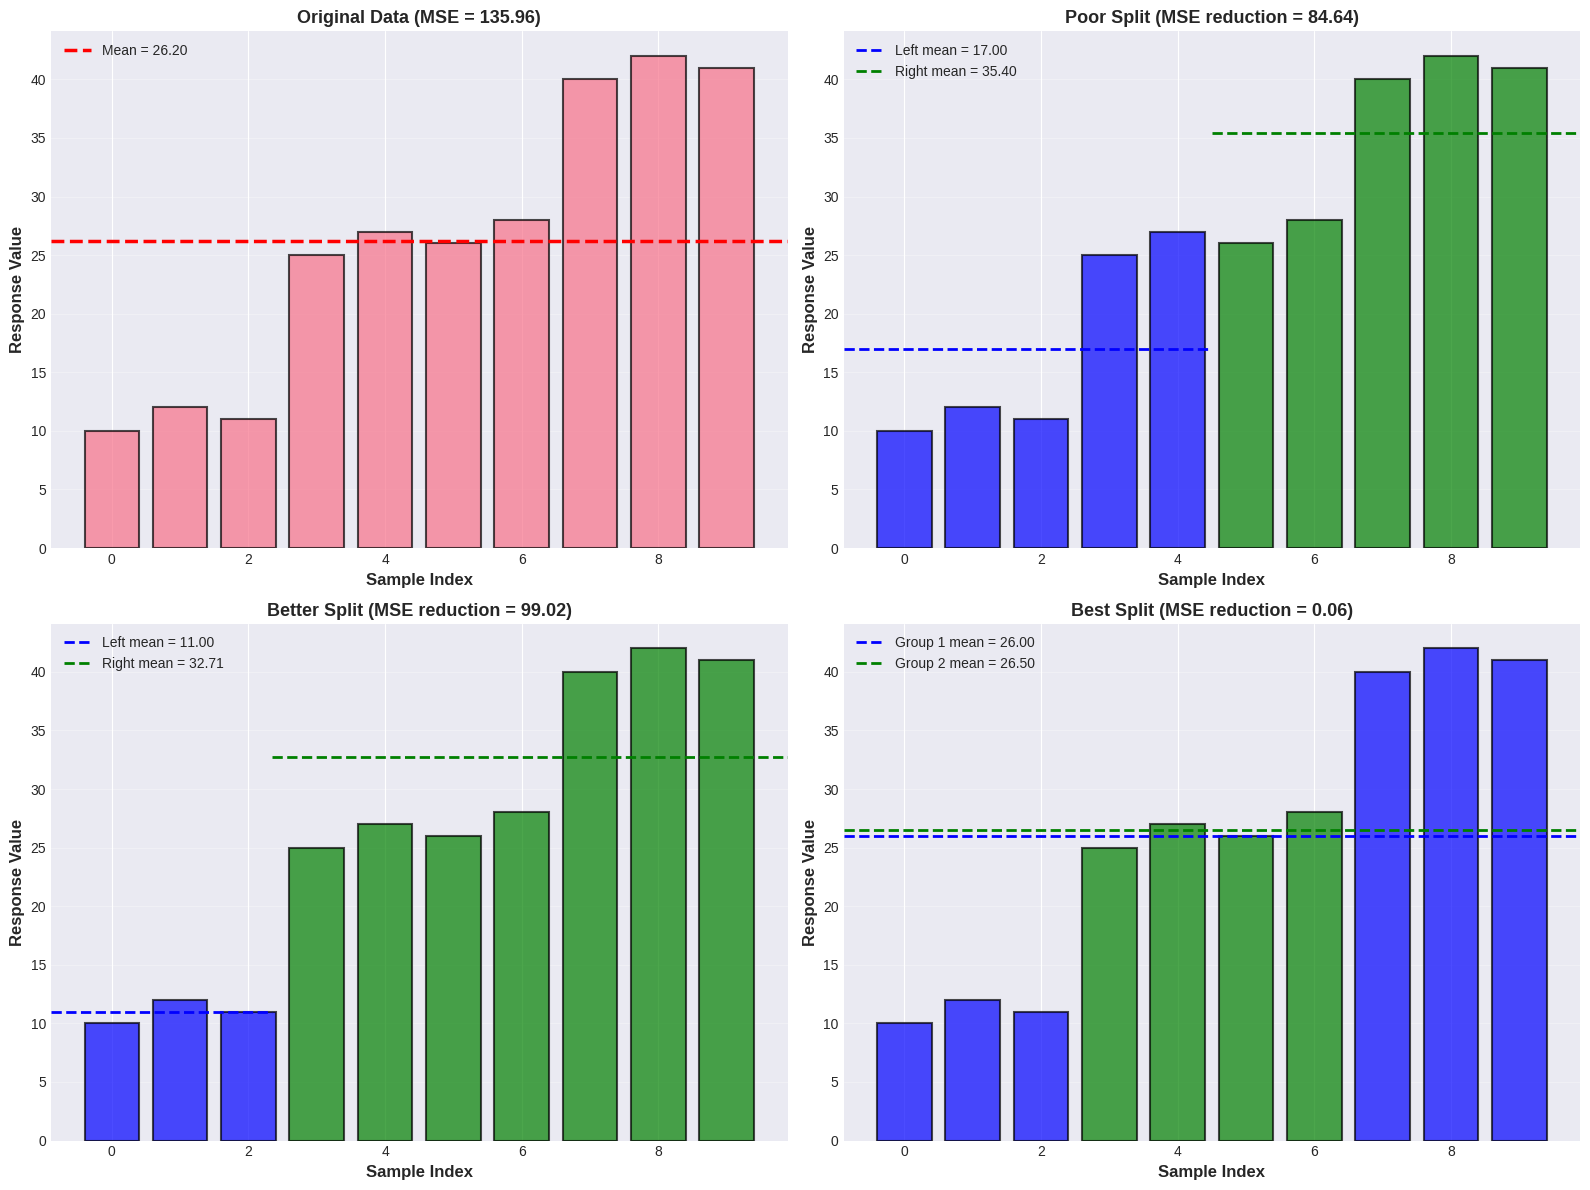


Visualization Insights:
  - Best split creates most homogeneous groups
  - Group means are far apart
  - Within-group variance is minimized
  - Maximum MSE reduction achieved


In [3]:
# Visualize MSE reduction

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original data
ax = axes[0, 0]
x_pos = np.arange(len(y_example))
mean_y = np.mean(y_example)
ax.bar(x_pos, y_example, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=mean_y, color='r', linestyle='--', linewidth=2.5, label=f'Mean = {mean_y:.2f}')
ax.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Response Value', fontsize=12, fontweight='bold')
ax.set_title(f'Original Data (MSE = {calculate_mse(y_example):.2f})', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Poor split
ax = axes[0, 1]
y_left_poor = y_example[:5]
y_right_poor = y_example[5:]
colors = ['blue']*5 + ['green']*5
ax.bar(x_pos, y_example, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=np.mean(y_left_poor), color='blue', linestyle='--', linewidth=2,
          xmax=0.5, label=f'Left mean = {np.mean(y_left_poor):.2f}')
ax.axhline(y=np.mean(y_right_poor), color='green', linestyle='--', linewidth=2,
          xmin=0.5, label=f'Right mean = {np.mean(y_right_poor):.2f}')
reduction = calculate_mse_reduction(y_example, y_left_poor, y_right_poor)[0]
ax.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Response Value', fontsize=12, fontweight='bold')
ax.set_title(f'Poor Split (MSE reduction = {reduction:.2f})',
            fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Good split
ax = axes[1, 0]
y_left_good = y_example[:3]
y_right_good = y_example[3:]
colors = ['blue']*3 + ['green']*7
ax.bar(x_pos, y_example, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=np.mean(y_left_good), color='blue', linestyle='--', linewidth=2,
          xmax=0.3, label=f'Left mean = {np.mean(y_left_good):.2f}')
ax.axhline(y=np.mean(y_right_good), color='green', linestyle='--', linewidth=2,
          xmin=0.3, label=f'Right mean = {np.mean(y_right_good):.2f}')
reduction = calculate_mse_reduction(y_example, y_left_good, y_right_good)[0]
ax.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Response Value', fontsize=12, fontweight='bold')
ax.set_title(f'Better Split (MSE reduction = {reduction:.2f})',
            fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Best split
ax = axes[1, 1]
y_left_best = np.concatenate([y_example[:3], y_example[7:]])
y_right_best = y_example[3:7]
colors = ['blue']*3 + ['green']*4 + ['blue']*3
ax.bar(x_pos, y_example, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.axhline(y=np.mean(y_left_best), color='blue', linestyle='--', linewidth=2,
          label=f'Group 1 mean = {np.mean(y_left_best):.2f}')
ax.axhline(y=np.mean(y_right_best), color='green', linestyle='--', linewidth=2,
          label=f'Group 2 mean = {np.mean(y_right_best):.2f}')
reduction = calculate_mse_reduction(y_example, y_left_best, y_right_best)[0]
ax.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Response Value', fontsize=12, fontweight='bold')
ax.set_title(f'Best Split (MSE reduction = {reduction:.2f})',
            fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nVisualization Insights:")
print("  - Best split creates most homogeneous groups")
print("  - Group means are far apart")
print("  - Within-group variance is minimized")
print("  - Maximum MSE reduction achieved")

## 3. Finding Optimal Splits <a id='optimal-splits'></a>

### The Optimization Problem

At each node, we want to find the best feature $j$ and threshold $t$ that minimizes:

$$\min_{j,t} \left[\frac{|S_L|}{|S|}\text{MSE}(S_L) + \frac{|S_R|}{|S|}\text{MSE}(S_R)\right]$$

where:
$$S_L(j,t) = \{(\mathbf{x}, y) \in S | x_j \leq t\}$$
$$S_R(j,t) = \{(\mathbf{x}, y) \in S | x_j > t\}$$

### Greedy Search Algorithm

For continuous features, the search space is infinite. We use a greedy approach:

**Algorithm**:
```
best_mse_reduction = 0
best_feature = None
best_threshold = None

for each feature j:
    # Sort samples by feature j
    sorted_values = unique sorted values of feature j
    
    # Try midpoints between consecutive values
    for each consecutive pair (v1, v2) in sorted_values:
        threshold = (v1 + v2) / 2
        
        # Calculate MSE reduction
        split data into S_L and S_R using threshold
        reduction = calculate_mse_reduction(S, S_L, S_R)
        
        # Update best split if improvement
        if reduction > best_mse_reduction:
            best_mse_reduction = reduction
            best_feature = j
            best_threshold = threshold

return best_feature, best_threshold
```

### Why Midpoints?

For a sorted feature, the optimal split threshold must be between two consecutive training values:
- Any threshold in the interval $(v_i, v_{i+1})$ produces the same split
- We use midpoint for consistency: $t = \frac{v_i + v_{i+1}}{2}$

### Computational Complexity

For dataset with $n$ samples and $p$ features:
- **Sorting**: $O(n \log n)$ per feature
- **Trying splits**: $O(n)$ per feature
- **Total per node**: $O(p \times n \log n)$
- **Total for tree**: $O(p \times n \log n \times d)$ where $d$ is depth

### Optimization Tricks

**Pre-sorting**: Sort features once at root
- Maintain sorted indices for each child
- Reduces sorting cost in deeper nodes

**Histogram-based**: Bin continuous features
- Reduces number of candidate thresholds
- Trade-off between speed and accuracy
- Used in XGBoost, LightGBM

**Approximate splits**: Sample candidate thresholds
- Don't try all possible splits
- Faster with slight accuracy loss

In [4]:
# Implement optimal split finding

def find_best_split(X, y, feature_idx):
    """
    Find best threshold for splitting on a given feature
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        Training data
    y : array-like, shape (n_samples,)
        Target values
    feature_idx : int
        Index of feature to split on
    
    Returns:
    --------
    best_threshold : float
        Optimal split threshold
    best_mse_reduction : float
        MSE reduction achieved by best split
    """
    # Get feature values
    feature_values = X[:, feature_idx]
    
    # Get unique sorted values
    unique_values = np.unique(feature_values)
    
    if len(unique_values) <= 1:
        return None, 0
    
    # Parent MSE
    parent_mse = calculate_mse(y)
    
    best_threshold = None
    best_mse_reduction = 0
    
    # Try each midpoint between consecutive values
    for i in range(len(unique_values) - 1):
        threshold = (unique_values[i] + unique_values[i + 1]) / 2
        
        # Split data
        left_mask = feature_values <= threshold
        right_mask = ~left_mask
        
        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            continue
        
        y_left = y[left_mask]
        y_right = y[right_mask]
        
        # Calculate MSE reduction
        mse_reduction = calculate_mse_reduction(y, y_left, y_right)[0]
        
        # Update best split
        if mse_reduction > best_mse_reduction:
            best_mse_reduction = mse_reduction
            best_threshold = threshold
    
    return best_threshold, best_mse_reduction

def find_best_split_all_features(X, y):
    """
    Find best feature and threshold to split on
    """
    n_features = X.shape[1]
    
    best_feature = None
    best_threshold = None
    best_mse_reduction = 0
    
    # Try each feature
    for feature_idx in range(n_features):
        threshold, mse_reduction = find_best_split(X, y, feature_idx)
        
        if threshold is not None and mse_reduction > best_mse_reduction:
            best_mse_reduction = mse_reduction
            best_feature = feature_idx
            best_threshold = threshold
    
    return best_feature, best_threshold, best_mse_reduction

# Test on synthetic data
np.random.seed(42)
X_test = np.random.randn(100, 3)
y_test = 2 * X_test[:, 0] + 3 * X_test[:, 1] - X_test[:, 2] + np.random.randn(100) * 0.5

print("Finding Best Split:")
print("="*70)
print(f"Dataset: {X_test.shape[0]} samples, {X_test.shape[1]} features")
print(f"Response range: [{y_test.min():.2f}, {y_test.max():.2f}]")
print(f"Parent MSE: {calculate_mse(y_test):.4f}")

# Find best split for each feature
print("\n" + "="*70)
print("MSE Reduction by Feature:")
print("="*70)

for feature_idx in range(X_test.shape[1]):
    threshold, mse_reduction = find_best_split(X_test, y_test, feature_idx)
    print(f"\nFeature {feature_idx}:")
    print(f"  Best threshold: {threshold:.4f}")
    print(f"  MSE reduction: {mse_reduction:.4f}")
    print(f"  Percentage: {(mse_reduction/calculate_mse(y_test))*100:.2f}%")

# Find overall best split
best_feature, best_threshold, best_reduction = find_best_split_all_features(X_test, y_test)
print("\n" + "="*70)
print(f"Best overall split:")
print(f"  Feature: {best_feature}")
print(f"  Threshold: {best_threshold:.4f}")
print(f"  MSE reduction: {best_reduction:.4f}")

Finding Best Split:
Dataset: 100 samples, 3 features
Response range: [-7.88, 9.45]
Parent MSE: 13.3778

MSE Reduction by Feature:

Feature 0:
  Best threshold: 1.7259
  MSE reduction: 2.2745
  Percentage: 17.00%

Feature 1:
  Best threshold: -0.0758
  MSE reduction: 7.0473
  Percentage: 52.68%

Feature 2:
  Best threshold: -0.4432
  MSE reduction: 3.3139
  Percentage: 24.77%

Best overall split:
  Feature: 1
  Threshold: -0.0758
  MSE reduction: 7.0473


## 4. Continuous Feature Splits <a id='continuous-splits'></a>

### Handling Continuous Features

CART naturally handles continuous features through binary splits:
- **Left child**: $x_j \leq t$
- **Right child**: $x_j > t$

where $t$ is the threshold value.

### Split Selection Process

For a continuous feature with $n$ unique values:
1. Sort values: $v_1 < v_2 < \cdots < v_n$
2. Consider $n-1$ possible splits
3. Evaluate midpoints: $t_i = \frac{v_i + v_{i+1}}{2}$ for $i = 1, \ldots, n-1$
4. Choose split with maximum MSE reduction

### Why This Works

**Theorem**: The optimal split point on a continuous feature must lie between two consecutive training values.

**Proof sketch**:
- Within interval $(v_i, v_{i+1})$, all thresholds produce same split
- MSE reduction is piecewise constant function of threshold
- Maximum must occur at one of the breakpoints

### Advantages Over Discretization

**No need to bin features**:
- Automatic data-driven thresholds
- No loss of information from binning
- Different thresholds at different nodes

**Adaptive to data**:
- Split points determined by training data
- Can capture non-uniform distributions
- Each node can use different threshold

### Example: Multiple Uses of Same Feature

Unlike ID3, CART can split on the same feature multiple times with different thresholds:

```
            Age <= 30?
           /          \
         Yes           No
          |            |
    Age <= 20?    Age <= 50?
    /      \      /        \
```

This creates **hierarchical partitioning** of feature space.

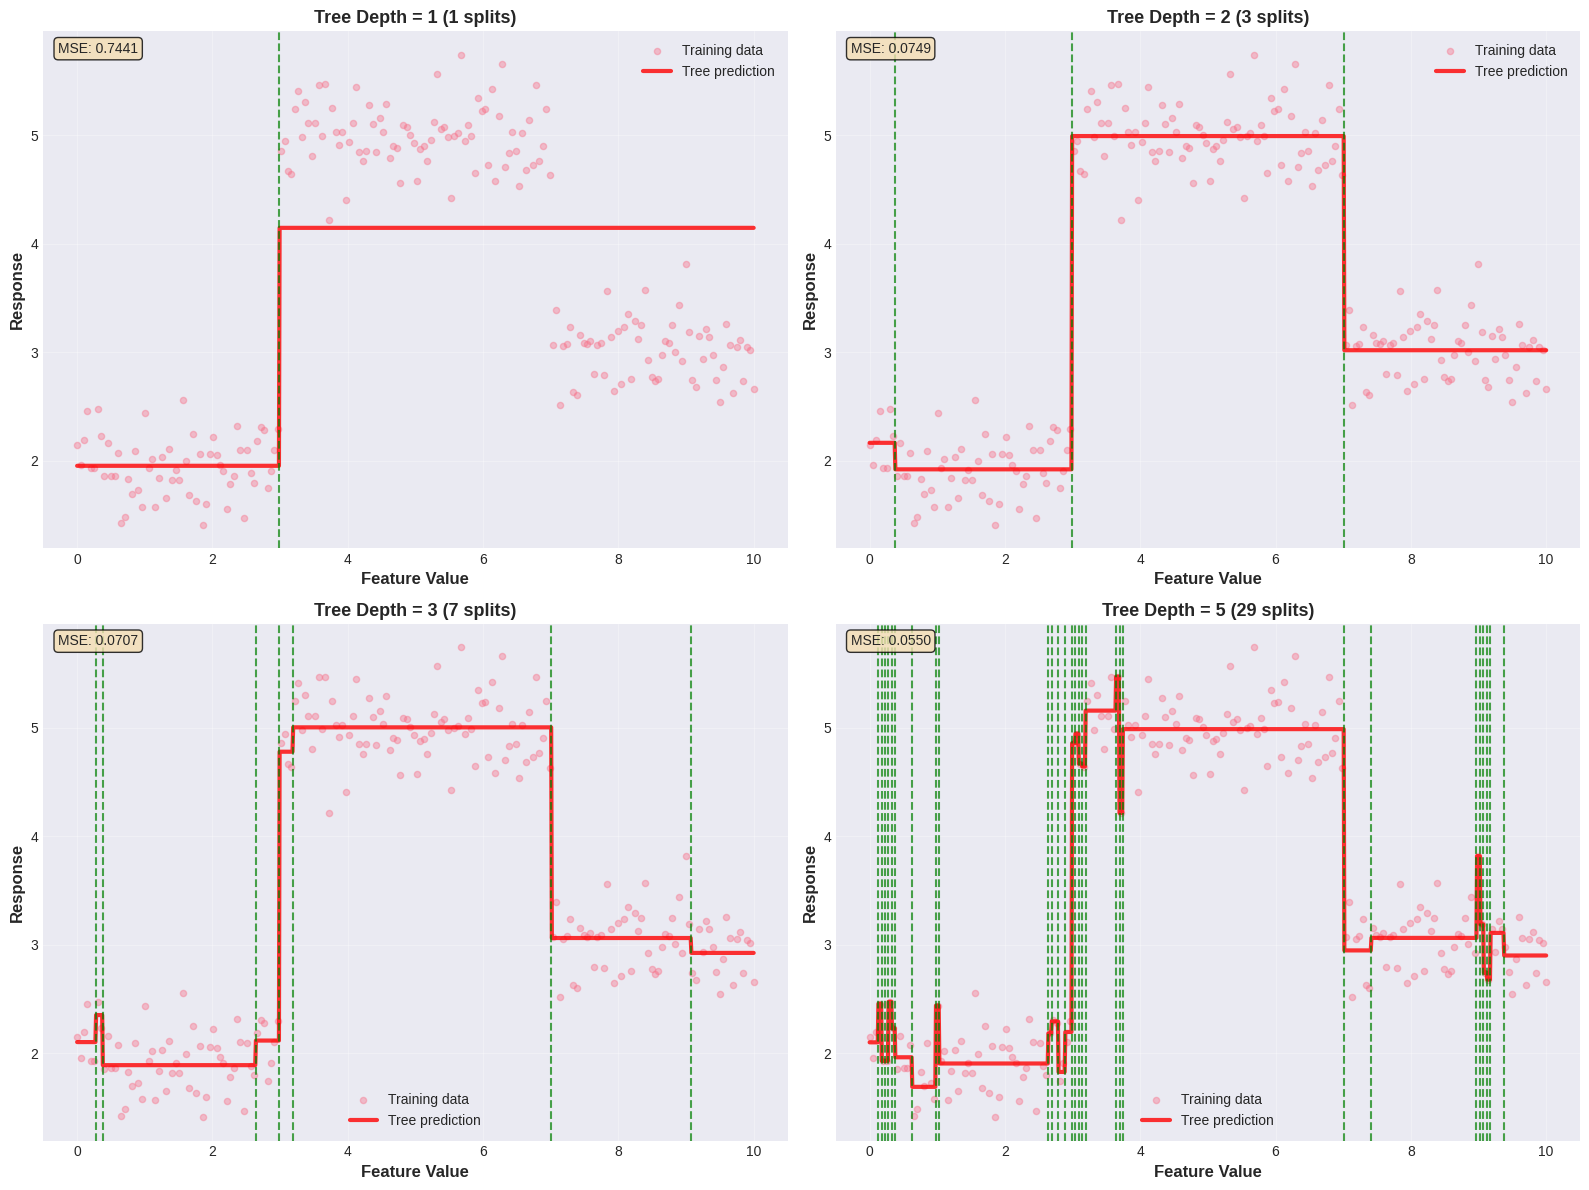

Continuous Feature Split Analysis:

Depth 1:
  Leaves: 2
  MSE: 0.7441
  R²: 0.5755

Depth 2:
  Leaves: 4
  MSE: 0.0749
  R²: 0.9573

Depth 3:
  Leaves: 8
  MSE: 0.0707
  R²: 0.9597

Depth 5:
  Leaves: 30
  MSE: 0.0550
  R²: 0.9686


In [5]:
# Visualize continuous feature splits

# Generate data with clear structure
np.random.seed(42)
n_samples = 200

# Create piecewise linear function
X_continuous = np.linspace(0, 10, n_samples).reshape(-1, 1)
y_continuous = np.zeros(n_samples)

# Three regions with different means
y_continuous[X_continuous[:, 0] < 3] = 2 + np.random.randn(np.sum(X_continuous[:, 0] < 3)) * 0.3
mask2 = (X_continuous[:, 0] >= 3) & (X_continuous[:, 0] < 7)
y_continuous[mask2] = 5 + np.random.randn(np.sum(mask2)) * 0.3
y_continuous[X_continuous[:, 0] >= 7] = 3 + np.random.randn(np.sum(X_continuous[:, 0] >= 7)) * 0.3

# Train regression trees with different depths
depths = [1, 2, 3, 5]
models = []

for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_continuous, y_continuous)
    models.append(model)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

X_plot = np.linspace(0, 10, 1000).reshape(-1, 1)

for idx, (depth, model) in enumerate(zip(depths, models)):
    ax = axes[idx]
    
    # Plot data points
    ax.scatter(X_continuous, y_continuous, alpha=0.4, s=20, label='Training data')
    
    # Plot predictions
    y_pred = model.predict(X_plot)
    ax.plot(X_plot, y_pred, 'r-', linewidth=3, label='Tree prediction', alpha=0.8)
    
    # Mark split points
    # Get split thresholds from tree
    tree = model.tree_
    thresholds = []
    
    def get_thresholds(node_id):
        if tree.feature[node_id] != -2:  # Not a leaf
            thresholds.append(tree.threshold[node_id])
            get_thresholds(tree.children_left[node_id])
            get_thresholds(tree.children_right[node_id])
    
    get_thresholds(0)
    
    for threshold in thresholds:
        ax.axvline(x=threshold, color='green', linestyle='--', 
                  linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Feature Value', fontsize=12, fontweight='bold')
    ax.set_ylabel('Response', fontsize=12, fontweight='bold')
    ax.set_title(f'Tree Depth = {depth} ({len(thresholds)} splits)',
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Calculate MSE
    y_pred_train = model.predict(X_continuous)
    mse = mean_squared_error(y_continuous, y_pred_train)
    ax.text(0.02, 0.98, f'MSE: {mse:.4f}',
           transform=ax.transAxes, fontsize=10,
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("Continuous Feature Split Analysis:")
print("="*70)
for depth, model in zip(depths, models):
    y_pred = model.predict(X_continuous)
    mse = mean_squared_error(y_continuous, y_pred)
    r2 = r2_score(y_continuous, y_pred)
    n_leaves = model.get_n_leaves()
    print(f"\nDepth {depth}:")
    print(f"  Leaves: {n_leaves}")
    print(f"  MSE: {mse:.4f}")
    print(f"  R²: {r2:.4f}")

## 5. Piecewise Constant Fitting <a id='piecewise-fitting'></a>

### Piecewise Constant Approximation

A regression tree creates a **piecewise constant function**:
$$\hat{f}(\mathbf{x}) = \sum_{m=1}^{M} c_m \cdot \mathbb{1}(\mathbf{x} \in R_m)$$

where:
- $M$ is the number of leaf nodes (regions)
- $R_m$ is the $m$-th region
- $c_m$ is the constant prediction in region $R_m$
- $\mathbb{1}(\cdot)$ is the indicator function

### Optimal Prediction Value

For region $R_m$ containing training samples $\{(\mathbf{x}_i, y_i) | \mathbf{x}_i \in R_m\}$, the optimal constant that minimizes MSE is:

$$c_m = \text{mean}(y_i \text{ for } \mathbf{x}_i \in R_m) = \frac{1}{|R_m|} \sum_{\mathbf{x}_i \in R_m} y_i$$

**Proof**: For squared loss, the optimal prediction is always the mean:
$$c_m^* = \arg\min_c \sum_{\mathbf{x}_i \in R_m} (y_i - c)^2$$

Taking derivative and setting to zero:
$$\frac{\partial}{\partial c} \sum (y_i - c)^2 = -2\sum(y_i - c) = 0$$
$$\Rightarrow c = \frac{1}{n}\sum y_i$$

### Properties

**Stepwise function**:
- Prediction is constant within each region
- Changes abruptly at region boundaries
- No smoothness guarantees

**Universal approximation**:
- Can approximate any continuous function
- With enough regions (leaves)
- Similar to histogram approximation

**Limitations**:
- Cannot extrapolate beyond training range
- Predictions are always within training response range
- Discontinuous at boundaries

### Comparison with Other Methods

| Method | Function Type | Extrapolation | Smoothness |
|--------|--------------|---------------|------------|
| Linear Regression | Linear | Yes | C∞ |
| Polynomial Regression | Polynomial | Yes | C∞ |
| Regression Trees | Piecewise Constant | No | Discontinuous |
| Splines | Piecewise Polynomial | Limited | Controlled |
| k-NN | Locally Constant | No | Discontinuous |

### Visual Representation

For 1D input, the piecewise constant function looks like a step function:
```
y |
  |     ___
  | ___|   |___
  |             |___
  +-----------------> x
   Region boundaries
```

For 2D input, regions are rectangles (axis-aligned):
- Each rectangle has constant prediction
- Rectangles are created by recursive binary splits
- Forms axis-aligned grid (not arbitrary polygons)

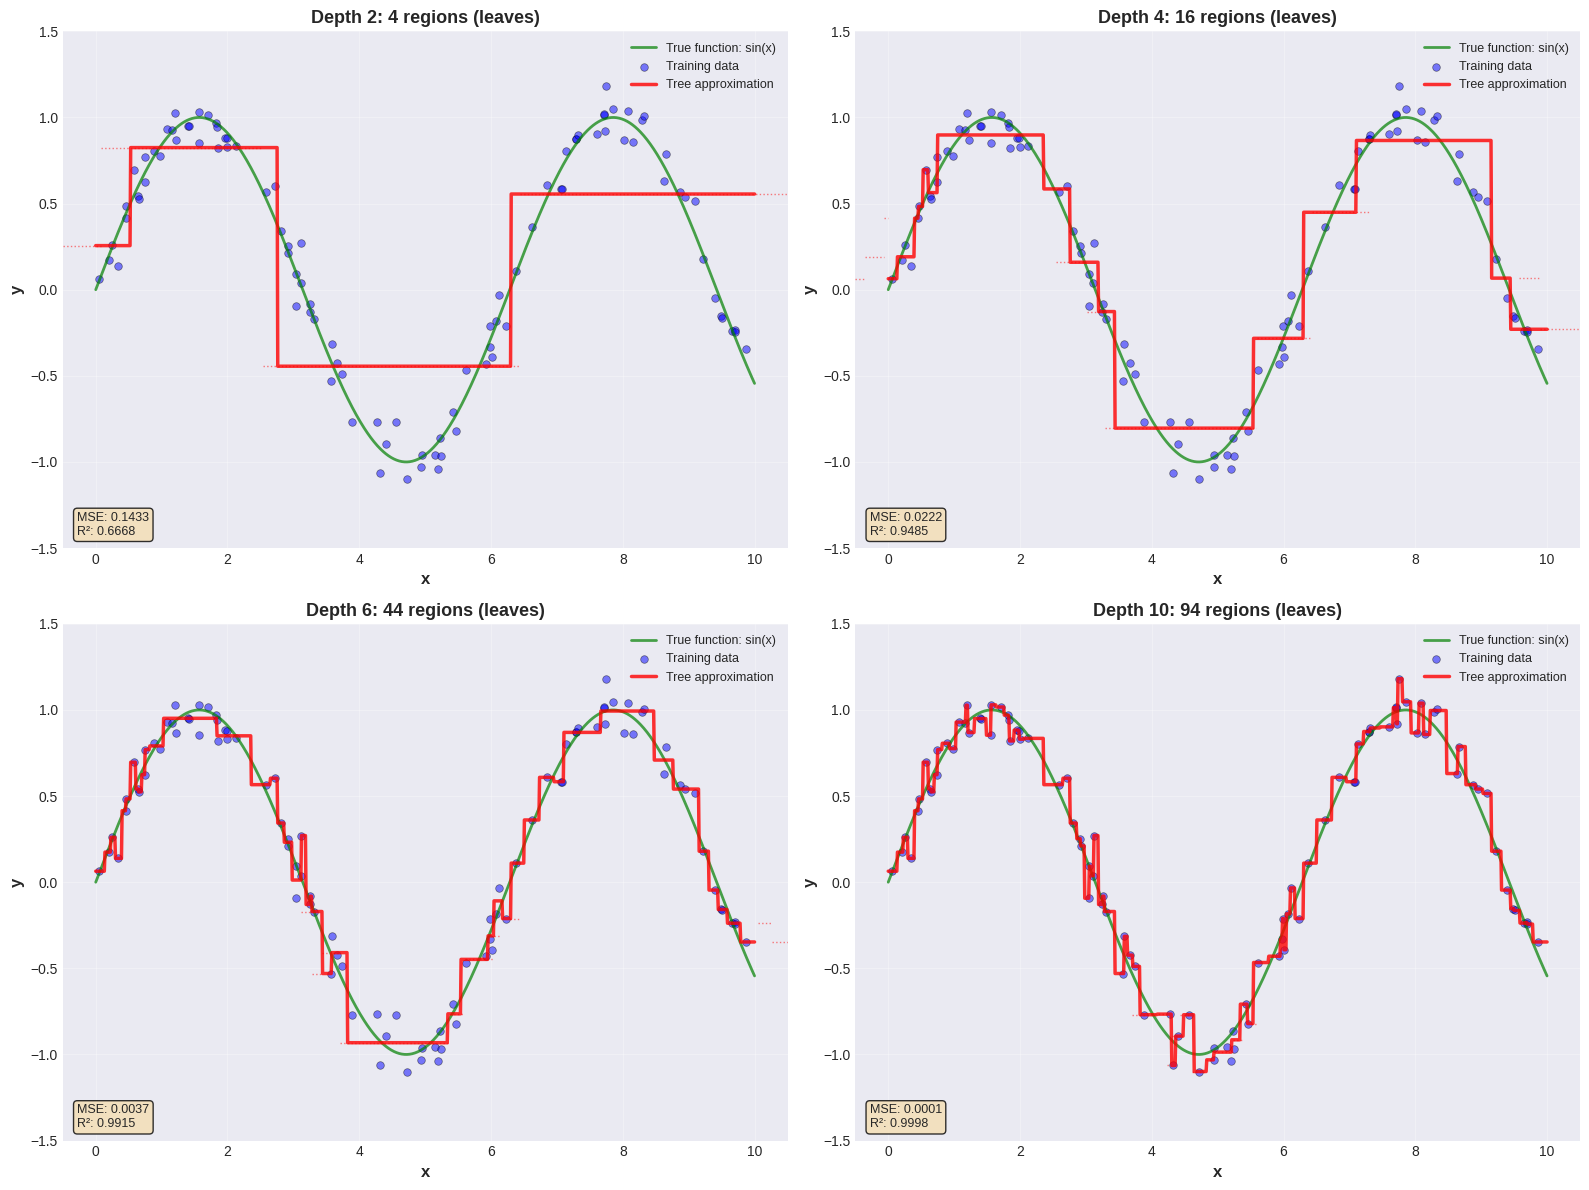

Piecewise Constant Approximation Analysis:

As tree depth increases:
  - More regions created (more leaves)
  - Better approximation of smooth function
  - But still piecewise constant (step function)
  - Training error decreases
  - Risk of overfitting increases

Depth | Leaves | MSE    | R²
-----------------------------------
   2  |    4   | 0.1433 | 0.6668
   4  |   16   | 0.0222 | 0.9485
   6  |   44   | 0.0037 | 0.9915
  10  |   94   | 0.0001 | 0.9998


In [6]:
# Demonstrate piecewise constant approximation

# Create smooth non-linear function
np.random.seed(42)
X_smooth = np.sort(np.random.rand(100, 1) * 10, axis=0)
y_smooth = np.sin(X_smooth).ravel() + np.random.randn(100) * 0.1

# Fit trees with different depths
depths_compare = [2, 4, 6, 10]
models_compare = []

for depth in depths_compare:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_smooth, y_smooth)
    models_compare.append(model)

# Create fine grid for plotting
X_plot_fine = np.linspace(0, 10, 1000).reshape(-1, 1)
y_true_fine = np.sin(X_plot_fine).ravel()

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, (depth, model) in enumerate(zip(depths_compare, models_compare)):
    ax = axes[idx]
    
    # Plot true function
    ax.plot(X_plot_fine, y_true_fine, 'g-', linewidth=2, 
           label='True function: sin(x)', alpha=0.7)
    
    # Plot training data
    ax.scatter(X_smooth, y_smooth, alpha=0.5, s=30, 
              label='Training data', color='blue', edgecolors='black', linewidths=0.5)
    
    # Plot tree prediction
    y_pred = model.predict(X_plot_fine)
    ax.plot(X_plot_fine, y_pred, 'r-', linewidth=2.5, 
           label='Tree approximation', alpha=0.8)
    
    # Highlight piecewise constant nature
    unique_predictions = np.unique(y_pred)
    for pred_value in unique_predictions[:10]:  # Show first 10 regions
        mask = y_pred == pred_value
        if np.sum(mask) > 0:
            x_min = X_plot_fine[mask].min()
            x_max = X_plot_fine[mask].max()
            ax.axhline(y=pred_value, xmin=(x_min/10), xmax=(x_max/10),
                      color='red', linestyle=':', linewidth=1, alpha=0.5)
    
    # Calculate errors
    y_pred_train = model.predict(X_smooth)
    mse = mean_squared_error(y_smooth, y_pred_train)
    r2 = r2_score(y_smooth, y_pred_train)
    n_leaves = model.get_n_leaves()
    
    ax.set_xlabel('x', fontsize=12, fontweight='bold')
    ax.set_ylabel('y', fontsize=12, fontweight='bold')
    ax.set_title(f'Depth {depth}: {n_leaves} regions (leaves)',
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-1.5, 1.5])
    
    # Add metrics
    ax.text(0.02, 0.02, f'MSE: {mse:.4f}\nR²: {r2:.4f}',
           transform=ax.transAxes, fontsize=9,
           verticalalignment='bottom',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("Piecewise Constant Approximation Analysis:")
print("="*70)
print("\nAs tree depth increases:")
print("  - More regions created (more leaves)")
print("  - Better approximation of smooth function")
print("  - But still piecewise constant (step function)")
print("  - Training error decreases")
print("  - Risk of overfitting increases")

print("\nDepth | Leaves | MSE    | R²")
print("-" * 35)
for depth, model in zip(depths_compare, models_compare):
    y_pred = model.predict(X_smooth)
    mse = mean_squared_error(y_smooth, y_pred)
    r2 = r2_score(y_smooth, y_pred)
    n_leaves = model.get_n_leaves()
    print(f"  {depth:2d}  |  {n_leaves:3d}   | {mse:.4f} | {r2:.4f}")

## 6. Building Regression Trees from Scratch <a id='building-trees'></a>

### Complete CART Algorithm

```python
def build_tree(X, y, depth=0, max_depth=None, min_samples_split=2):
    n_samples = len(y)
    
    # Stopping criteria
    if (depth >= max_depth or 
        n_samples < min_samples_split or
        np.var(y) < 1e-7):
        # Create leaf node with mean prediction
        return LeafNode(value=np.mean(y))
    
    # Find best split
    best_feature, best_threshold, best_mse_reduction = find_best_split(X, y)
    
    if best_feature is None or best_mse_reduction == 0:
        # No good split found
        return LeafNode(value=np.mean(y))
    
    # Split data
    left_mask = X[:, best_feature] <= best_threshold
    right_mask = ~left_mask
    
    # Recursively build subtrees
    left_subtree = build_tree(X[left_mask], y[left_mask], 
                              depth+1, max_depth, min_samples_split)
    right_subtree = build_tree(X[right_mask], y[right_mask],
                               depth+1, max_depth, min_samples_split)
    
    return DecisionNode(feature=best_feature, 
                       threshold=best_threshold,
                       left=left_subtree, 
                       right=right_subtree)
```

### Hyperparameters

**max_depth**: Maximum tree depth
- Controls model complexity
- Deeper = more complex = higher variance
- Typical values: 3-10

**min_samples_split**: Minimum samples to split node
- Must have at least this many samples to split
- Higher = more conservative = less overfitting
- Typical values: 2-20

**min_samples_leaf**: Minimum samples in leaf node
- Leaf must have at least this many samples
- Similar effect to min_samples_split
- Typical values: 1-10

**min_impurity_decrease**: Minimum MSE reduction to split
- Only split if MSE reduction exceeds this threshold
- Prevents splits that don't improve much
- Typical values: 0 (no constraint) or small positive

**max_leaf_nodes**: Maximum number of leaf nodes
- Limits total tree size
- Alternative to max_depth
- Grown in best-first manner

In [7]:
# Complete CART regression tree implementation

class RegressionTreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # For leaf nodes
    
    def is_leaf(self):
        return self.value is not None

class RegressionTreeCART:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1,
                 min_impurity_decrease=0.0):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_impurity_decrease = min_impurity_decrease
        self.root = None
        self.feature_names = None
    
    def fit(self, X, y, feature_names=None):
        self.feature_names = feature_names
        self.root = self._build_tree(X, y, depth=0)
        return self
    
    def _build_tree(self, X, y, depth):
        n_samples = len(y)
        
        # Stopping criteria
        if (self.max_depth is not None and depth >= self.max_depth) or \
           n_samples < self.min_samples_split or \
           np.var(y) < 1e-7:
            return RegressionTreeNode(value=np.mean(y))
        
        # Find best split
        best_feature, best_threshold, best_mse_reduction = self._find_best_split(X, y)
        
        # Check if split is good enough
        if best_feature is None or best_mse_reduction < self.min_impurity_decrease:
            return RegressionTreeNode(value=np.mean(y))
        
        # Split data
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        # Check min_samples_leaf
        if np.sum(left_mask) < self.min_samples_leaf or \
           np.sum(right_mask) < self.min_samples_leaf:
            return RegressionTreeNode(value=np.mean(y))
        
        # Recursively build subtrees
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return RegressionTreeNode(feature=best_feature, 
                                 threshold=best_threshold,
                                 left=left_subtree, 
                                 right=right_subtree)
    
    def _find_best_split(self, X, y):
        n_features = X.shape[1]
        best_feature = None
        best_threshold = None
        best_mse_reduction = 0
        
        parent_mse = np.var(y)
        
        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])
            
            for i in range(len(thresholds) - 1):
                threshold = (thresholds[i] + thresholds[i + 1]) / 2
                
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                # Calculate MSE reduction
                n_left = np.sum(left_mask)
                n_right = np.sum(right_mask)
                n = len(y)
                
                left_mse = np.var(y[left_mask])
                right_mse = np.var(y[right_mask])
                weighted_mse = (n_left / n) * left_mse + (n_right / n) * right_mse
                mse_reduction = parent_mse - weighted_mse
                
                if mse_reduction > best_mse_reduction:
                    best_mse_reduction = mse_reduction
                    best_feature = feature_idx
                    best_threshold = threshold
        
        return best_feature, best_threshold, best_mse_reduction
    
    def predict(self, X):
        return np.array([self._predict_sample(x, self.root) for x in X])
    
    def _predict_sample(self, x, node):
        if node.is_leaf():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._predict_sample(x, node.left)
        return self._predict_sample(x, node.right)
    
    def get_depth(self, node=None):
        if node is None:
            node = self.root
        
        if node.is_leaf():
            return 1
        
        return 1 + max(self.get_depth(node.left), self.get_depth(node.right))
    
    def get_n_leaves(self, node=None):
        if node is None:
            node = self.root
        
        if node.is_leaf():
            return 1
        
        return self.get_n_leaves(node.left) + self.get_n_leaves(node.right)

print("CART Regression Tree implementation complete")

CART Regression Tree implementation complete


CART Regression Tree Results:
Dataset: 442 samples, 10 features
Training samples: 353
Test samples: 89

Our Implementation:
  MSE: 3466.6610
  R²: 0.3457
  MAE: 46.4493
  Tree depth: 5
  Number of leaves: 14

Scikit-learn Implementation:
  MSE: 3441.5364
  R²: 0.3504
  MAE: 46.3038
  Tree depth: 4
  Number of leaves: 14


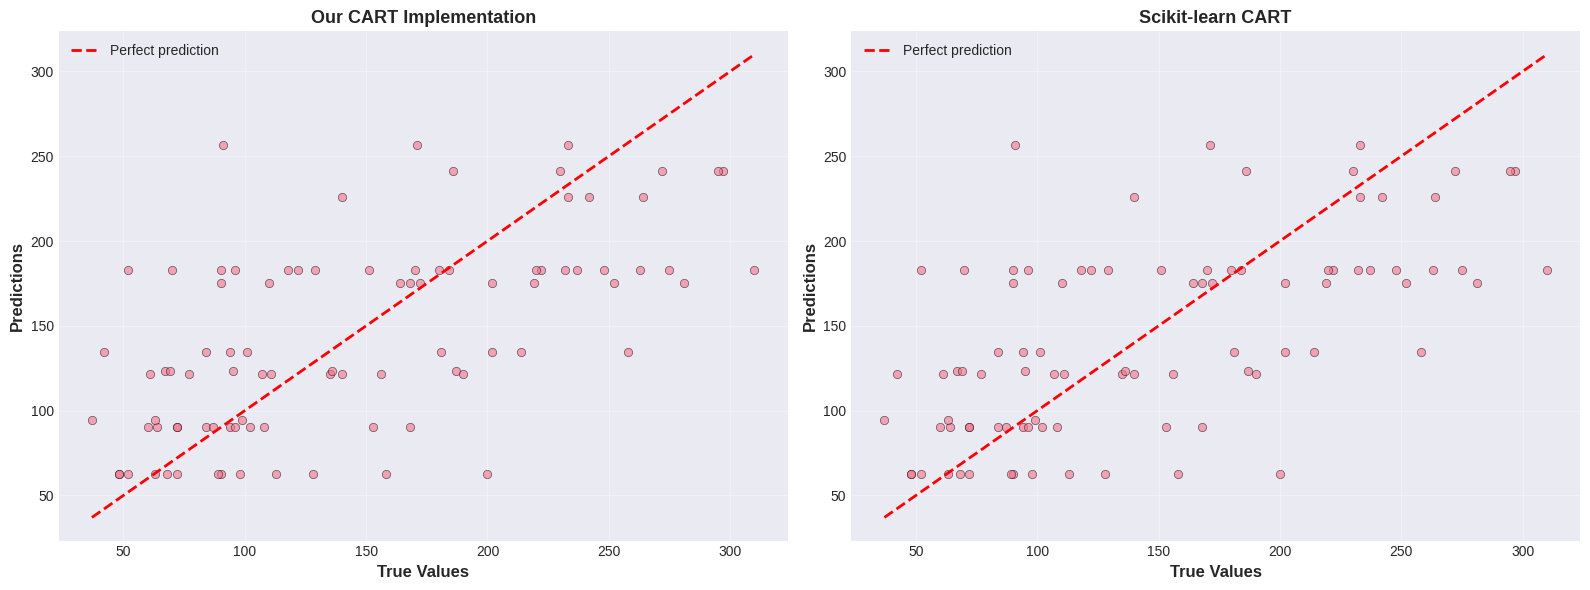

In [8]:
# Test CART implementation

# Load diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train our implementation
tree_cart = RegressionTreeCART(max_depth=4, min_samples_split=10)
tree_cart.fit(X_train, y_train)

# Train sklearn for comparison
tree_sklearn = DecisionTreeRegressor(max_depth=4, min_samples_split=10, random_state=42)
tree_sklearn.fit(X_train, y_train)

# Predictions
y_pred_cart = tree_cart.predict(X_test)
y_pred_sklearn = tree_sklearn.predict(X_test)

# Evaluate
print("CART Regression Tree Results:")
print("="*70)
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

print("\nOur Implementation:")
print(f"  MSE: {mean_squared_error(y_test, y_pred_cart):.4f}")
print(f"  R²: {r2_score(y_test, y_pred_cart):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_cart):.4f}")
print(f"  Tree depth: {tree_cart.get_depth()}")
print(f"  Number of leaves: {tree_cart.get_n_leaves()}")

print("\nScikit-learn Implementation:")
print(f"  MSE: {mean_squared_error(y_test, y_pred_sklearn):.4f}")
print(f"  R²: {r2_score(y_test, y_pred_sklearn):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred_sklearn):.4f}")
print(f"  Tree depth: {tree_sklearn.get_depth()}")
print(f"  Number of leaves: {tree_sklearn.get_n_leaves()}")

# Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Our implementation
ax = axes[0]
ax.scatter(y_test, y_pred_cart, alpha=0.6, edgecolors='black', linewidths=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
        'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('True Values', fontsize=12, fontweight='bold')
ax.set_ylabel('Predictions', fontsize=12, fontweight='bold')
ax.set_title('Our CART Implementation', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Sklearn implementation
ax = axes[1]
ax.scatter(y_test, y_pred_sklearn, alpha=0.6, edgecolors='black', linewidths=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
        'r--', linewidth=2, label='Perfect prediction')
ax.set_xlabel('True Values', fontsize=12, fontweight='bold')
ax.set_ylabel('Predictions', fontsize=12, fontweight='bold')
ax.set_title('Scikit-learn CART', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary and Key Takeaways

### Core Concepts

**CART Algorithm**: Binary tree builder for classification and regression
- Uses MSE reduction for regression tasks
- Greedy, top-down construction
- Handles continuous features naturally

**MSE Reduction**: Splitting criterion for regression
- Measures variance reduction after split
- Always non-negative
- Equivalent to maximizing between-group variance

**Piecewise Constant Fit**: Tree prediction model
- Constant prediction in each leaf
- Mean of training samples in region
- Creates step function approximation

**Continuous Splits**: How CART handles numeric features
- Binary splits at data-driven thresholds
- Can reuse same feature with different thresholds
- No need for feature binning

### Advantages

- Simple and interpretable
- No feature scaling needed
- Handles non-linear relationships
- Automatic feature selection
- Works with continuous and categorical features
- Fast prediction time

### Limitations

- Prone to overfitting without regularization
- High variance (sensitive to data changes)
- Piecewise constant (not smooth)
- Cannot extrapolate
- Greedy algorithm (not globally optimal)
- Biased toward features with many unique values

### Best Practices

1. **Control tree size**: Use max_depth, min_samples_split
2. **Cross-validate**: Select hyperparameters carefully
3. **Consider pruning**: Remove unnecessary splits
4. **Use ensembles**: Random Forest, Gradient Boosting
5. **Check for overfitting**: Compare train/test performance

CART trees are the building blocks for powerful ensemble methods like Random Forests and Gradient Boosted Trees.